# 17 — Sintéticos III: laboratorio de detectores con régimen conocido

Este notebook ejecuta los detectores del benchmark sobre trayectorias sintéticas cuya secuencia de
régimen se conoce **exactamente**, y mide cómo recuperan las crisis, cuánto tardan, cómo se degradan
al hacer el problema más difícil y si el orden que producen se parece al ranking real ADR-003.
Las cifras que cita el texto proceden de las salidas de las celdas.

## 0. Enfoque, preguntas y riesgos

**Por qué una simulación controlada.** El notebook 16 no admitió ningún generador como
`apto_laboratorio` ni como `laboratorio_condicionado`: el discriminador separa todos los sintéticos del
real y todos fallan la dependencia dentro de racha. Un laboratorio que pretendiera «reproducir el
mercado» no tendría base. Por eso (decisión del 2026-10-05, declarada en `configs/sinteticos.yaml →
laboratorio`) el 17 es un **estudio de simulación controlada**: se usan solo los tres generadores
paramétricos con mecanismo explícito (`gaussiano_regimen`, `var_regimen`, `garch_regimen`), ajustados
en el 15 con el tramo de train, como *mundos de juguete* con verdad-terreno exacta. El laboratorio
ordena detectores por **robustez y mecanismo**; **no** mide su rendimiento en el mercado real.

**Diseño (pre-registrado antes de ejecutar ningún detector).**

- Trayectoria = calentamiento (igual al train inicial del benchmark: 2016 sesiones en A, 756 en B)
  + 1260 sesiones puntuadas fuera de muestra. Mismo `walk_forward`, mismas specs (features, `step`,
  ventana) que el benchmark; solo cambia el panel.
- Secuencia de régimen **impuesta**: crisis de duración fija en el calentamiento (2 en A, 1 en B) y
  2 crisis en el tramo puntuado, con inicio sorteado dentro de su hueco.
- Rejilla por pista: **generador (3) × duración de crisis (21, 63, 252 sesiones) × intensidad
  (λ = 1,0 nativa; 0,5 atenuada)** = 18 celdas. Con λ la media y la dispersión de cada columna en crisis
  se interpolan entre las de calma y las nativas. Las celdas que solo difieren en λ comparten la
  trayectoria bruta (diseño pareado).
- Detectores: los 12 en A; en B quedan fuera D02 y D10, porque usan columnas que los generadores no
  producen.

**Preguntas e hipótesis (pre-registro).**

| | Pregunta | Hipótesis |
|---|---|---|
| H1 | ¿Recupera cada detector la secuencia verdadera? | Con crisis de 252 sesiones y λ = 1, la mayoría supera el azar (lift > 1) y detecta ≥ la mitad de las crisis |
| H2 | ¿Cómo se degrada con la dificultad? | El score baja al acortar la crisis y al atenuarla (se publica el efecto, sin exigir monotonía) |
| H3 | ¿Coincide el orden del laboratorio con el ranking real ADR-003? | Spearman entre score medio de laboratorio y score real, con p por permutación |
| H4 | ¿Hay circularidad (detectores que «juegan en casa»)? | Ventaja de D03/D04 en `gaussiano_regimen` y de D06/D11 en `garch_regimen` frente a los otros generadores |

**Riesgos y cómo se leen.**

- **Optimismo de laboratorio:** los mundos de juguete son más estacionarios y limpios que el real.
- **Circularidad:** un detector cuyo modelo coincide con el del generador tiene ventaja. La H4 la mide
  y se descuenta en la lectura.
- **Fuga:** los generadores se ajustaron solo con el train (15). El ranking real se lee **solo** en
  la comparación final (H3).
- **Coste:** el número de trayectorias por celda (11) se fijó con un piloto que midió solo tiempos.


## 1. Configuración y pre-registro

In [1]:
%matplotlib inline
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from regimenes import rutas
from regimenes.sinteticos.laboratorio import analisis as an
from regimenes.sinteticos.laboratorio import ejecucion as ej
from regimenes.sinteticos.laboratorio import escenarios as esc

warnings.filterwarnings('ignore')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

EJECUTAR = False  # True = lanza la rejilla (reanudable, ~8 h); False = lee la caché de results/
CFG = esc.config_laboratorio()
DIR = ej.DIR_RESULTADOS
FIGS = DIR / 'figuras'
FIGS.mkdir(parents=True, exist_ok=True)
PISTAS = CFG['pistas']

pre = {k: CFG[k] for k in ('generadores', 'duraciones', 'intensidades', 'largo_puntuado',
                           'crisis_calentamiento', 'crisis_puntuadas', 'margen_min', 'n_paths',
                           'presupuesto_horas', 'n_jobs', 'excluir', 'misma_familia', 'min_run', 'n_boot')}
display(pd.Series({k: json.dumps(v, ensure_ascii=False) for k, v in pre.items()}, name='valor').to_frame())
for p in PISTAS:
    print(f'Pista {p}: {len(esc.celdas(p, CFG))} celdas, largo {esc.largo_total(p, CFG)} sesiones '
          f'(calentamiento {esc.CALENTAMIENTO[p]}), detectores {esc.detectores_pista(p, CFG)}')

,valor
generadores,"[""gaussiano_regimen"", ""var_regimen"", ""garch_re..."
duraciones,"[21, 63, 252]"
intensidades,"[1.0, 0.5]"
largo_puntuado,1260
crisis_calentamiento,"{""A"": 2, ""B"": 1}"
crisis_puntuadas,2
margen_min,21
n_paths,11
presupuesto_horas,8
n_jobs,10


Pista A: 18 celdas, largo 3276 sesiones (calentamiento 2016), detectores ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12']
Pista B: 18 celdas, largo 2016 sesiones (calentamiento 756), detectores ['D01', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D11', 'D12']


**Piloto de coste.** Se ejecutó una trayectoria de la primera celda por pista y detector con 10
procesos. Solo se miraron los tiempos: con ellos se fijó `n_paths`, como declara el yaml.

In [2]:
piloto = pd.read_csv(DIR / 'piloto_coste.csv')
display(piloto.pivot_table(index='id', columns='pista', values='segundos').round(1))
print('Errores en el piloto:', piloto.loc[piloto.estado != 'ok', ['pista', 'id']].values.tolist())

pista,A,B
id,,
D01,0.9,0.8
D02,0.9,NaN
D03,24.1,18.5
D04,207.0,104.8
D05,131.7,91.4
D06,12.5,8.5
D07,2.2,1.9
D08,70.9,35.4
D09,94.5,38.1


Errores en el piloto: [['A', 'D11']]


## 2. Diseño de escenarios

La figura muestra la secuencia de régimen impuesta para cada duración (trayectoria 0, pista A) y
cómo la intensidad λ cambia la serie de retornos de una misma trayectoria bruta.

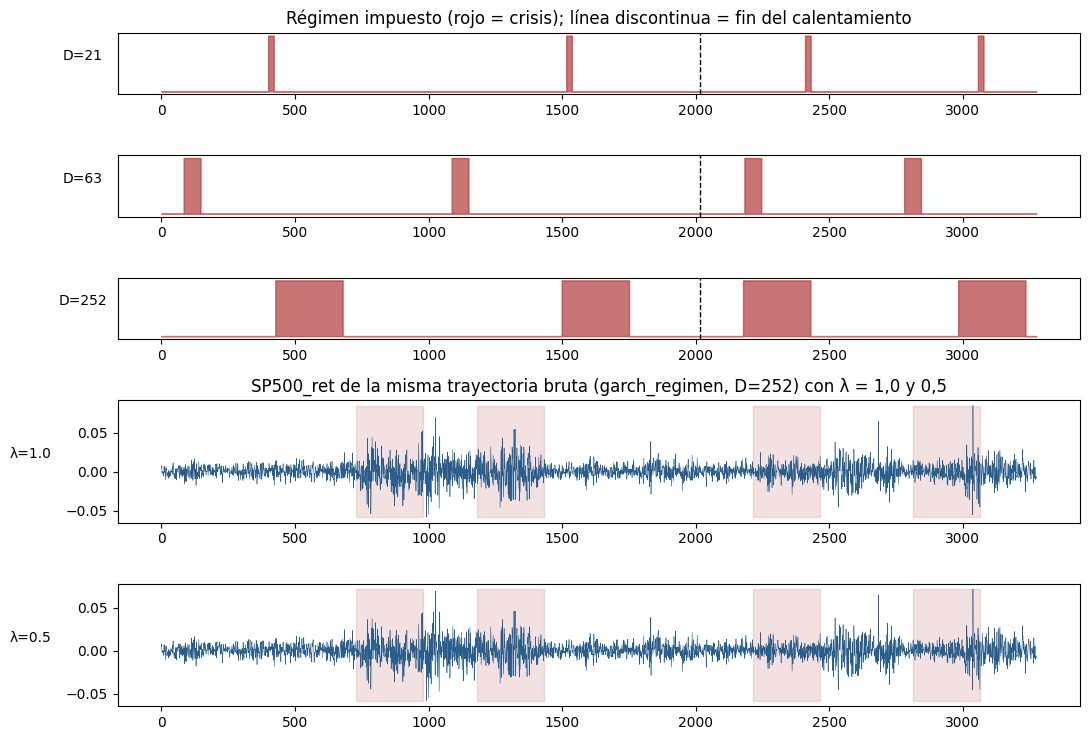

In [3]:
fig, axs = plt.subplots(len(CFG['duraciones']) + 2, 1, figsize=(11, 7.5), sharex=False,
                        gridspec_kw={'height_ratios': [1] * len(CFG['duraciones']) + [2, 2]})
celdas_A = esc.celdas('A', CFG)
for ax, d in zip(axs, CFG['duraciones']):
    c = next(c for c in celdas_A if c.duracion == d and c.intensidad == 1.0)
    t = pd.read_parquet(ej.ruta_trayectoria(c, 0))
    ax.fill_between(range(len(t)), t['regime'], step='mid', color='#B23A3A', alpha=0.7)
    ax.axvline(esc.CALENTAMIENTO['A'], color='k', ls='--', lw=1)
    ax.set_yticks([]); ax.set_ylabel(f'D={d}', rotation=0, labelpad=25)
axs[0].set_title('Régimen impuesto (rojo = crisis); línea discontinua = fin del calentamiento')
for ax, lam in zip(axs[-2:], CFG['intensidades']):
    c = next(c for c in celdas_A if c.generador == 'garch_regimen' and c.duracion == 252 and c.intensidad == lam)
    t = pd.read_parquet(ej.ruta_trayectoria(c, 0))
    ax.plot(range(len(t)), t['SP500_ret'], lw=0.4, color='#2B5D8A')
    ax.fill_between(range(len(t)), t['SP500_ret'].min(), t['SP500_ret'].max(), where=t['regime'] == 1,
                    color='#B23A3A', alpha=0.15)
    ax.set_ylabel(f'λ={lam}', rotation=0, labelpad=25)
axs[-2].set_title('SP500_ret de la misma trayectoria bruta (garch_regimen, D=252) con λ = 1,0 y 0,5')
fig.tight_layout(); fig.savefig(FIGS / 'escenarios.png', dpi=130); plt.show()

**Comprobación de sanidad de la rejilla.** Por celda: fracción de días de crisis en el tramo
puntuado y cociente de desviación típica de `SP500_ret` (crisis/calma). Con λ = 0,5 el cociente debe
quedar entre 1 y el de λ = 1.

In [4]:
filas = []
for p in PISTAS:
    for c in esc.celdas(p, CFG):
        for k in range(CFG['n_paths']):
            ruta = ej.ruta_trayectoria(c, k)
            if not ruta.exists():
                continue
            t = pd.read_parquet(ruta, columns=['SP500_ret', 'regime'])
            punt = t.iloc[esc.CALENTAMIENTO[p]:]
            sd = t.groupby('regime')['SP500_ret'].std()
            filas.append({**c.to_row(), 'path_id': k, 'frac_crisis_puntuada': punt['regime'].mean(),
                          'cociente_sd': sd.get(1, np.nan) / sd.get(0, np.nan)})
sanidad = pd.DataFrame(filas)
tabla_sanidad = sanidad.groupby(['pista', 'generador', 'duracion', 'intensidad'])[
    ['frac_crisis_puntuada', 'cociente_sd']].mean().round(3).unstack('intensidad')
display(tabla_sanidad)
print('Trayectorias por celda:', sanidad.groupby(['pista', 'celda']).size().describe()[['min', 'max']].to_dict())

frac_crisis_puntuada        cociente_sd       
intensidad                                        0.5    1.0         0.5    1.0
pista generador         duracion                                               
A     garch_regimen     21                      0.033  0.033       1.041  1.076
                        63                      0.100  0.100       1.136  1.270
                        252                     0.400  0.400       1.354  1.709
      gaussiano_regimen 21                      0.033  0.033       1.272  1.539
                        63                      0.100  0.100       1.270  1.539
                        252                     0.400  0.400       1.270  1.539
      var_regimen       21                      0.033  0.033       1.221  1.436
                        63                      0.100  0.100       1.275  1.548
                        252                     0.400  0.400       1.256  1.512
B     garch_regimen     21                      0.033  0.033       1.161  1.315
                        63                      0.100  0.100       1.366  1.730
                        252                     0.400  0.400       1.628  2.255
      gaussiano_regimen 21                      0.033  0.033       1.617  2.227
                        63                      0.100  0.100       1.630  2.257
                        252                     0.400  0.400       1.610  2.219
      var_regimen       21                      0.033  0.033       1.638  2.269
                        63                      0.100  0.100       1.619  2.235
                        252                     0.400  0.400       1.657  2.314

Trayectorias por celda: {'min': 11.0, 'max': 11.0}


## 3. Ejecución de detectores sobre las trayectorias

`EJECUTAR = True` lanza la rejilla completa, la misma que la CLI `python -m regimenes.sinteticos.laboratorio`
(reanudable, con caché por huella). Con `False` se consolidan las filas ya calculadas.

In [5]:
if EJECUTAR:
    ej.preparar_trayectorias(PISTAS, CFG['n_paths'], CFG)
    estado = ej.ejecutar_lote(ej.trabajos(PISTAS, CFG['n_paths'], CFG), n_jobs=CFG['n_jobs'])
    display(estado['estado'].value_counts())
F = ej.consolidar()
F = F[F['path_id'] < CFG['n_paths']]
esperadas = {p: len(esc.celdas(p, CFG)) * CFG['n_paths'] * len(esc.detectores_pista(p, CFG)) for p in PISTAS}
cob = F.groupby('pista').size().rename('filas').to_frame()
cob['esperadas'] = pd.Series(esperadas)
display(cob)
print('Horas de CPU acumuladas:', round(F['segundos'].sum() / 3600, 1))
estado_ej = DIR / 'estado_ejecucion.csv'
if estado_ej.exists():
    e = pd.read_csv(estado_ej)
    display(e['estado'].value_counts().to_frame())
    if (e['estado'] == 'error').any():
        display(e.loc[e['estado'] == 'error', ['pista', 'celda', 'path_id', 'id', 'detalle']].head(20))

,filas,esperadas
pista,,
A,2376,2376
B,1980,1980


Horas de CPU acumuladas: 71.1


,count
estado,
ok,4246
cache,110


## 4. Métricas contra la verdad-terreno

Para cada (celda, trayectoria, detector) se calculan sobre el tramo puntuado las métricas ADR-003:
`score_deteccion` (F1 entre precisión diaria y recall por evento con racha ≥ 3), precisión, lift sobre
la tasa base y recall por evento. Se añaden tres **exploratorias** (no pre-registradas, ver el yaml) que solo existen con verdad exacta:
**retraso** (sesiones desde el inicio de la crisis hasta la primera racha de 3 marcas; solo en crisis
detectadas, así que se lee junto al recall por evento), **exactitud equilibrada** diaria y **falsas
alarmas por año de calma** (episodios de marca que empiezan en calma, sin exigir racha mínima: los
detectores que parpadean salen penalizados).

La figura muestra la trayectoria 0 de una celda intermedia: la señal de crisis de algunos detectores
frente a la verdad.

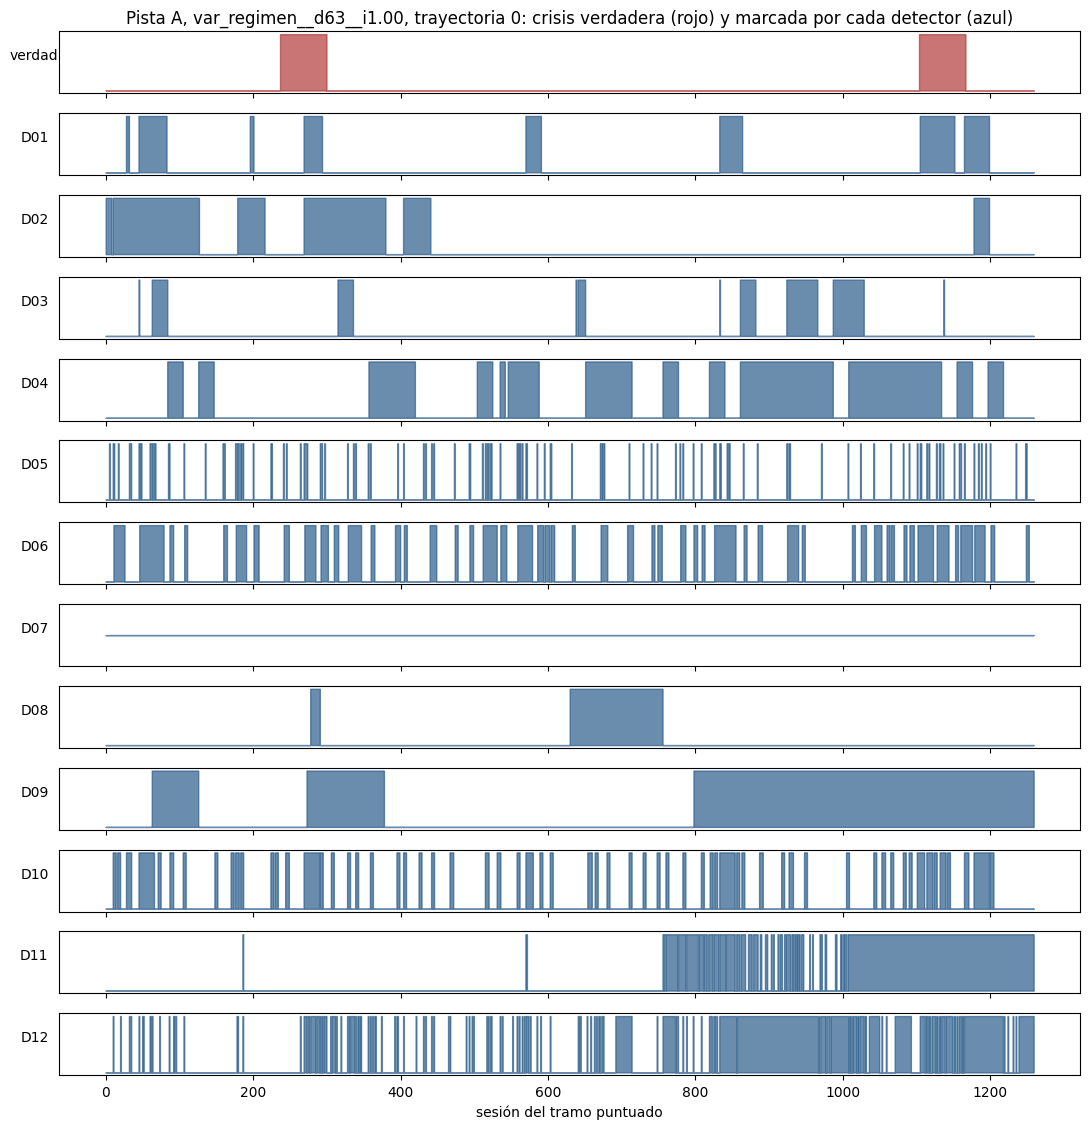

In [6]:
def panel_ejemplo(pista, celda, ids):
    fig, axs = plt.subplots(len(ids) + 1, 1, figsize=(11, 0.8 * (len(ids) + 1) + 1), sharex=True)
    tray = pd.read_parquet(ej.ruta_trayectoria(celda, 0))
    verdad = tray['regime'].iloc[esc.CALENTAMIENTO[pista]:].to_numpy()
    for ax, d in zip(axs[1:], ids):
        ax.set_yticks([]); ax.set_ylabel(d, rotation=0, labelpad=18)
        ruta = ej.ruta_panel(celda, 0, d)
        if not ruta.exists():
            continue
        p = pd.read_parquet(ruta)
        marca = p['state'].eq(ej._spec(pista, d).factory().crisis_state)
        ax.fill_between(range(len(p)), marca, step='mid', color='#2B5D8A', alpha=0.7)
    axs[0].fill_between(range(len(verdad)), verdad, step='mid', color='#B23A3A', alpha=0.7)
    axs[0].set_yticks([]); axs[0].set_ylabel('verdad', rotation=0, labelpad=18)
    axs[0].set_title(f'Pista {pista}, {celda.clave}, trayectoria 0: crisis verdadera (rojo) y marcada por cada detector (azul)')
    axs[-1].set_xlabel('sesión del tramo puntuado')
    fig.tight_layout()
    return fig

c_ej = next(c for c in esc.celdas('A', CFG) if c.generador == 'var_regimen' and c.duracion == 63 and c.intensidad == 1.0)
fig = panel_ejemplo('A', c_ej, esc.detectores_pista('A', CFG))
fig.savefig(FIGS / 'ejemplo_paneles_A.png', dpi=130); plt.show()

**Nota sobre la figura.** La marca de cada detector es su estado canónico de crisis (`n_states − 1`),
el mismo que usan las métricas.

In [7]:
R = an.resumen_celdas(F, n_boot=CFG['n_boot'])
R.to_csv(DIR / 'resumen_celdas.csv', index=False)
metricas = ['score_deteccion', 'det_event_recall', 'det_precision', 'det_lift_precision',
            'exactitud_equilibrada', 'retraso_medio', 'falsas_alarmas_ano']
global_det = F.groupby(['pista', 'id'])[metricas].mean().round(3)
display(global_det)

score_deteccion  det_event_recall  det_precision  det_lift_precision  exactitud_equilibrada  retraso_medio  falsas_alarmas_ano
pista id                                                                                                                                 
A     D01            0.432             0.765          0.361               2.184                  0.633         27.616               1.252
      D02            0.390             0.727          0.334               2.043                  0.636         30.150               2.031
      D03            0.357             0.765          0.277               1.589                  0.575         24.528               5.825
      D04            0.308             0.859          0.220               1.239                  0.566         20.924               1.599
      D05            0.352             0.654          0.318               2.021                  0.593         23.640              12.496
      D06            0.380             0.876          0.298               1.545                  0.635         20.167               5.751
      D07            0.174             0.303          0.313               1.683                  0.522         47.950               0.161
      D08            0.297             0.588          0.243               1.375                  0.555         32.378               1.273
      D09            0.249             0.652          0.189               1.012                  0.515         25.745               0.401
      D10            0.440             0.975          0.335               2.115                  0.660          6.730               9.185
      D11            0.272             0.586          0.240               1.525                  0.540         25.069               8.392
      D12            0.314             0.828          0.228               1.264                  0.570         18.170              24.382
B     D01            0.424             0.874          0.360               2.081                  0.640         22.789               4.436
      D03            0.498             0.866          0.421               3.234                  0.692         18.524               3.471
      D04            0.401             0.904          0.311               1.887                  0.673         11.240               1.746
      D05            0.521             0.889          0.445               3.530                  0.702         12.433              14.093
      D06            0.472             0.962          0.382               2.152                  0.747         12.753               4.174
      D07            0.369             0.626          0.377               2.646                  0.612         35.167               0.323
      D08            0.448             0.747          0.374               2.696                  0.645         26.438               1.318
      D09            0.299             0.765          0.227               1.298                  0.551         32.067               0.473
      D11            0.420             0.821          0.351               2.685                  0.637         20.111              13.142
      D12            0.294             0.848          0.205               1.158                  0.538         18.921              32.813

## 5. Matriz generador × detector y lectura por hipótesis

### 5.1 Mapa de calor del score por celda

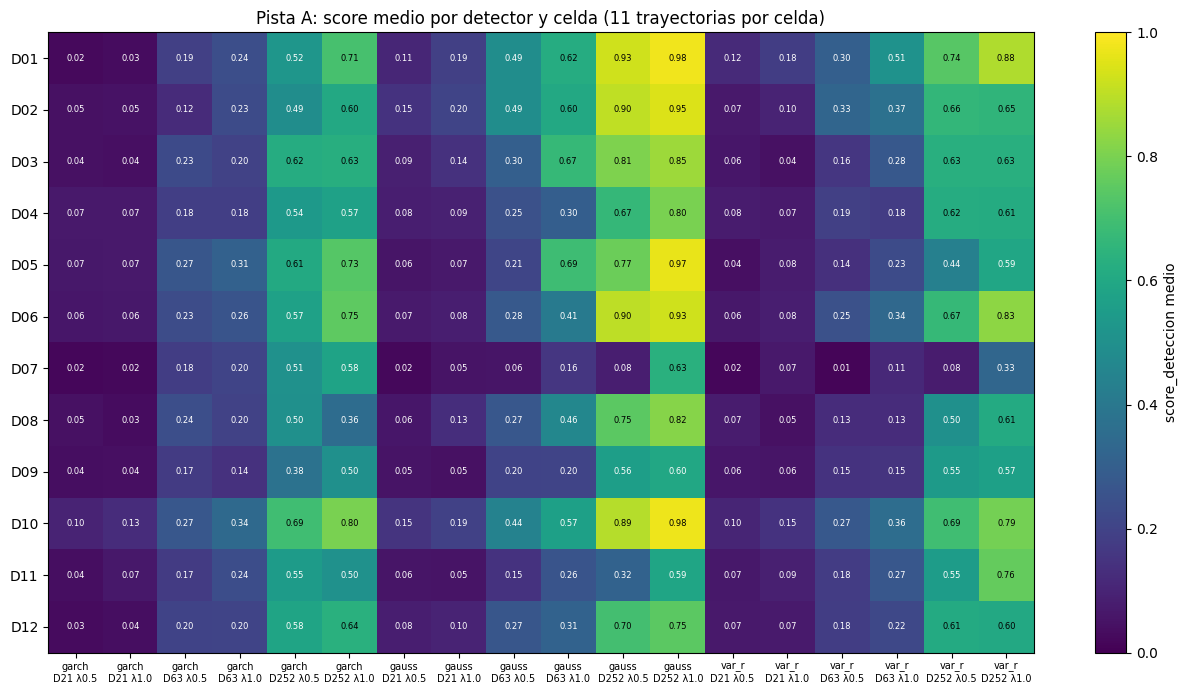

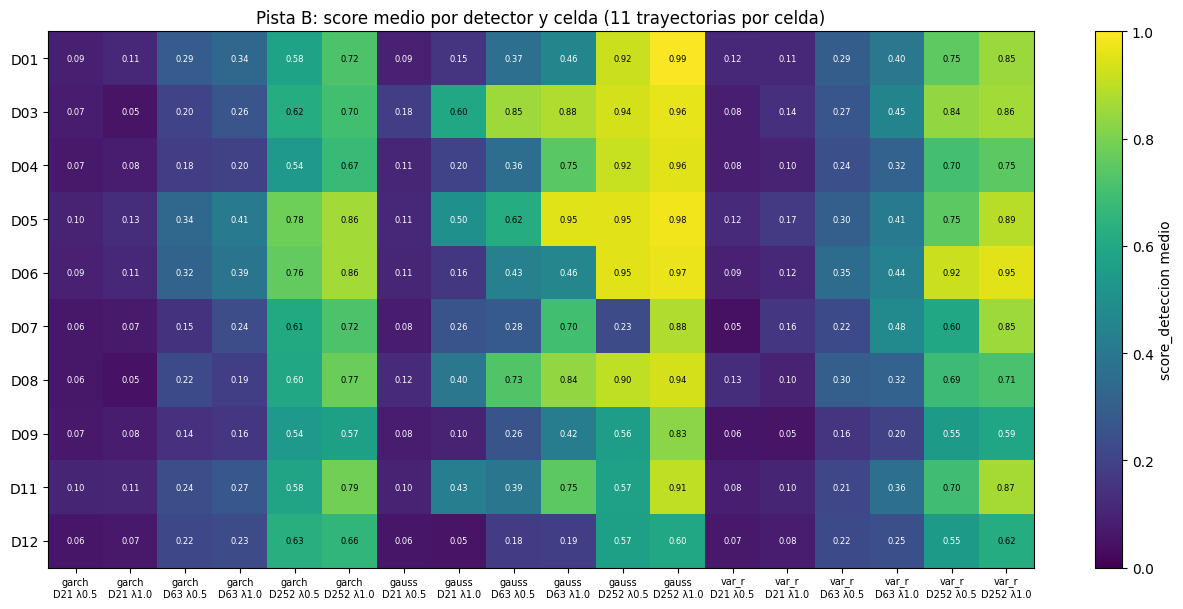

In [8]:
for p in PISTAS:
    m = R[R.pista == p].pivot_table(index='id', columns=['generador', 'duracion', 'intensidad'], values='media')
    fig, ax = plt.subplots(figsize=(13, 0.42 * len(m) + 2))
    im = ax.imshow(m.to_numpy(), cmap='viridis', vmin=0, vmax=1, aspect='auto')
    ax.set_yticks(range(len(m)), m.index)
    ax.set_xticks(range(m.shape[1]), [f'{g[:5]}\nD{d} λ{i}' for g, d, i in m.columns], fontsize=7)
    for (i, j), v in np.ndenumerate(m.to_numpy()):
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6, color='w' if v < 0.6 else 'k')
    fig.colorbar(im, ax=ax, label='score_deteccion medio')
    ax.set_title(f'Pista {p}: score medio por detector y celda ({CFG["n_paths"]} trayectorias por celda)')
    fig.tight_layout(); fig.savefig(FIGS / f'matriz_score_{p}.png', dpi=130); plt.show()

### 5.2 H1: recuperación en la celda fácil (D = 252, λ = 1)

In [9]:
H1 = an.h1_recuperacion(F)
H1.to_csv(DIR / 'h1_recuperacion.csv', index=False)
display(H1.pivot_table(index='id', columns=['pista', 'generador'], values='cumple').astype('boolean'))
res_h1 = H1.groupby(['pista', 'generador'])['cumple'].agg(['sum', 'count'])
res_h1['fraccion'] = (res_h1['sum'] / res_h1['count']).round(2)
display(res_h1)
for p in PISTAS:
    print(f'H1 pista {p}: cumplen {H1[(H1.pista == p)].cumple.mean():.0%} de los pares generador-detector '
          f'(la mayoría = más del 50 %)')

pista                 A                                           B                              
generador garch_regimen gaussiano_regimen var_regimen garch_regimen gaussiano_regimen var_regimen
id                                                                                               
D01                True              True        True          True              True        True
D02                True              True        True          <NA>              <NA>        <NA>
D03                True              True        True          True              True        True
D04                True              True        True          True              True        True
D05                True              True        True          True              True        True
D06                True              True        True          True              True        True
D07                True              True       False          True              True        True
D08               False              True        True          True              True        True
D09               False              True        True          True              True        True
D10                True              True        True          <NA>              <NA>        <NA>
D11                True              True        True          True              True        True
D12                True              True        True          True              True        True

sum  count  fraccion
pista generador                              
A     garch_regimen       10     12      0.83
      gaussiano_regimen   12     12      1.00
      var_regimen         11     12      0.92
B     garch_regimen       10     10      1.00
      gaussiano_regimen   10     10      1.00
      var_regimen         10     10      1.00

H1 pista A: cumplen 92% de los pares generador-detector (la mayoría = más del 50 %)
H1 pista B: cumplen 100% de los pares generador-detector (la mayoría = más del 50 %)


### 5.3 H2: degradación con la dificultad

`efecto_acortar` es la diferencia de score medio entre D = 21 y D = 252 (media sobre generadores e
intensidades, con IC bootstrap; trayectorias distintas, sin parear). `efecto_atenuar` es la diferencia **pareada** por trayectoria entre λ = 0,5 y λ = 1, con
IC 95 % bootstrap. Un valor negativo significa que el detector empeora.

,pista,id,efecto_acortar,acortar_ic_lo,acortar_ic_hi,efecto_atenuar,atenuar_ic_lo,atenuar_ic_hi
0,A,D01,-0.685,-0.724,-0.638,-0.102,-0.127,-0.082
1,A,D02,-0.607,-0.644,-0.567,-0.056,-0.077,-0.038
2,A,D03,-0.625,-0.660,-0.590,-0.060,-0.098,-0.022
3,A,D04,-0.558,-0.587,-0.532,-0.023,-0.043,-0.005
4,A,D05,-0.623,-0.671,-0.572,-0.127,-0.172,-0.083
5,A,D06,-0.704,-0.734,-0.673,-0.072,-0.092,-0.054
6,A,D07,-0.335,-0.400,-0.268,-0.132,-0.181,-0.084
7,A,D08,-0.525,-0.577,-0.469,-0.024,-0.064,0.021
8,A,D09,-0.476,-0.510,-0.436,-0.017,-0.039,0.002
9,A,D10,-0.670,-0.686,-0.654,-0.076,-0.085,-0.067


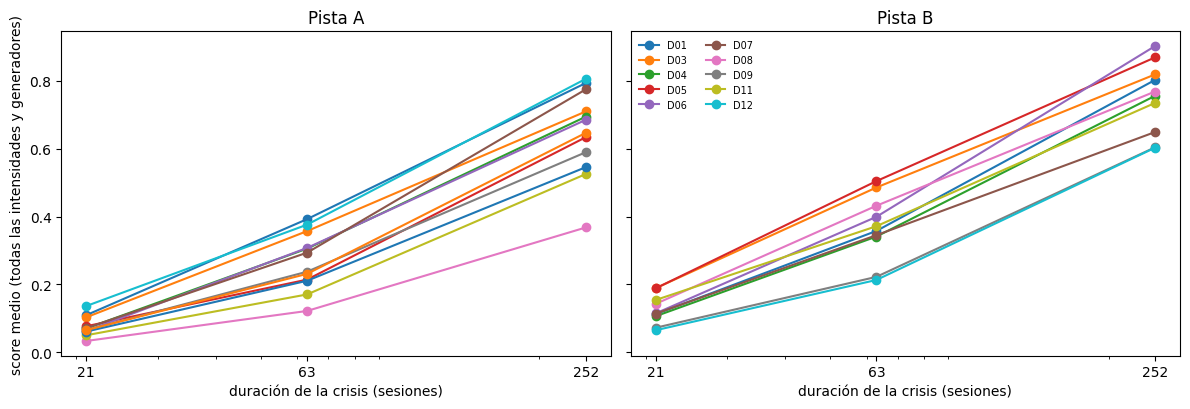

Pista A: empeoran al acortar (IC por debajo de 0) 12/12; empeoran al atenuar (IC por debajo de 0) 10/12
Pista B: empeoran al acortar (IC por debajo de 0) 10/10; empeoran al atenuar (IC por debajo de 0) 10/10


In [10]:
H2 = an.h2_degradacion(F, n_boot=CFG['n_boot'])
H2.to_csv(DIR / 'h2_degradacion.csv', index=False)
display(H2.round(3))
fig, axs = plt.subplots(1, len(PISTAS), figsize=(12, 4.2), sharey=True)
for ax, p in zip(np.atleast_1d(axs), PISTAS):
    s = F[F.pista == p].groupby(['id', 'duracion'])['score_deteccion'].mean().unstack('id')
    for d in s.columns:
        ax.plot(s.index, s[d], marker='o', label=d)
    ax.set_xscale('log'); ax.set_xticks(CFG['duraciones'], [str(x) for x in CFG['duraciones']])
    ax.set_xlabel('duración de la crisis (sesiones)'); ax.set_title(f'Pista {p}')
np.atleast_1d(axs)[0].set_ylabel('score medio (todas las intensidades y generadores)')
np.atleast_1d(axs)[-1].legend(ncol=2, fontsize=7, frameon=False)
fig.tight_layout(); fig.savefig(FIGS / 'degradacion_duracion.png', dpi=130); plt.show()
for p in PISTAS:
    h = H2[H2.pista == p]
    print(f'Pista {p}: empeoran al acortar (IC por debajo de 0) {int((h.acortar_ic_hi < 0).sum())}/{len(h)}; '
          f'empeoran al atenuar (IC por debajo de 0) {int((h.atenuar_ic_hi < 0).sum())}/{len(h)}')

**Dificultad frente a prevalencia.** Al acortar la crisis cambian dos cosas a la vez: el problema es
más difícil (hay menos sesiones para acumular evidencia) y la tasa base del tramo puntuado cae de 0,40
a 0,033, lo que por sí solo hunde la precisión alcanzable y con ella el F1. Para separarlas se mira
el recall por evento (no depende de la prevalencia) junto a la precisión y el lift.

In [11]:
desc = F.groupby(['pista', 'duracion'])[['det_base_rate', 'det_event_recall', 'det_precision',
                                         'det_lift_precision', 'score_deteccion']].mean().round(3)
display(desc)

det_base_rate  det_event_recall  det_precision  det_lift_precision  score_deteccion
pista duracion                                                                                     
A     21                0.033             0.542          0.051               1.541            0.075
      63                0.100             0.745          0.190               1.898            0.268
      252               0.400             0.857          0.584               1.460            0.648
B     21                0.033             0.681          0.087               2.600            0.125
      63                0.100             0.881          0.271               2.709            0.367
      252               0.400             0.929          0.676               1.689            0.751

### 5.4 H3: ¿coincide el orden del laboratorio con el ranking real?

El ranking real (ADR-003, `results/benchmark/ranking_v2.csv`) se lee aquí por primera vez. El score de
laboratorio es la media de las 18 celdas.

,score_lab,puesto_lab,score_deteccion,puesto_deteccion
id,,,,
D10,0.440,1,0.614,1
D01,0.432,2,0.587,2
D02,0.390,3,0.559,4
D06,0.380,4,0.540,7
D03,0.357,5,0.565,3
D05,0.352,6,0.546,5
D12,0.314,7,0.545,6
D04,0.308,8,0.455,10
D08,0.297,9,0.467,9


,score_lab,puesto_lab,score_deteccion,puesto_deteccion
id,,,,
D05,0.521,1,0.647,1
D03,0.498,2,0.241,10
D06,0.472,3,0.597,2
D08,0.448,4,0.274,9
D01,0.424,5,0.505,3
D11,0.420,6,0.394,8
D04,0.401,7,0.497,5
D07,0.369,8,0.426,7
D09,0.299,9,0.000,11


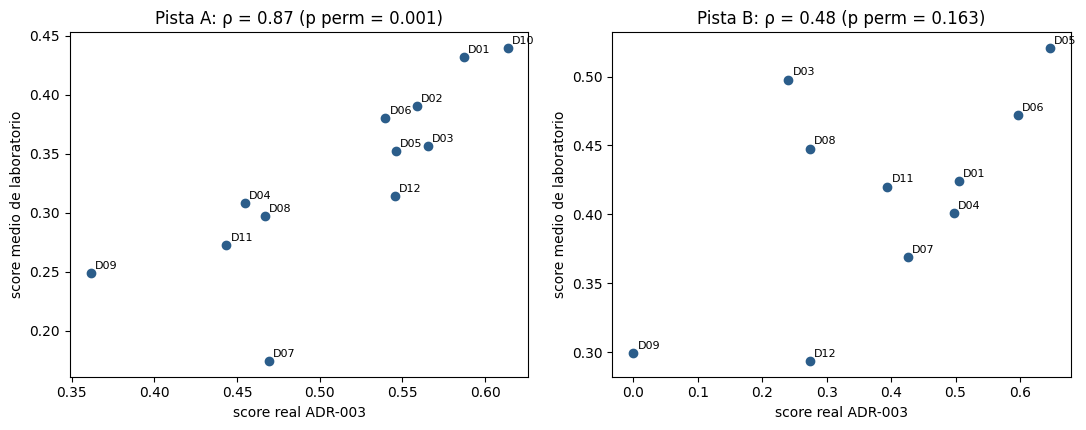

,pista,n_detectores,rho,p_perm
0,A,12,0.867,0.001
1,B,10,0.479,0.162


In [12]:
real = pd.read_csv(rutas.RESULTS_BENCHMARK / 'ranking_v2.csv')
H3 = []
fig, axs = plt.subplots(1, len(PISTAS), figsize=(11, 4.4))
for ax, p in zip(np.atleast_1d(axs), PISTAS):
    rk = an.ranking_laboratorio(F, p)
    rp = real[real.pista == p]
    res = an.h3_concordancia(rk, rp)
    H3.append({'pista': p, **res})
    comb = rk.join(rp.set_index('id')[['score_deteccion', 'puesto_deteccion']])
    comb.to_csv(DIR / f'ranking_laboratorio_{p}.csv')
    ax.scatter(comb['score_deteccion'], comb['score_lab'], color='#2B5D8A')
    for d, r in comb.iterrows():
        ax.annotate(d, (r['score_deteccion'], r['score_lab']), fontsize=8, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('score real ADR-003'); ax.set_ylabel('score medio de laboratorio')
    ax.set_title(f'Pista {p}: ρ = {res["rho"]:.2f} (p perm = {res["p_perm"]:.3f})')
    display(comb.round(3))
fig.tight_layout(); fig.savefig(FIGS / 'concordancia_ranking.png', dpi=130); plt.show()
H3 = pd.DataFrame(H3); H3.to_csv(DIR / 'h3_concordancia.csv', index=False); display(H3.round(3))

### 5.5 H4: circularidad

`ventaja_casa` es el score del detector en «su» generador menos su score medio en los otros dos (IC
bootstrap remuestreando trayectorias, con el mismo remuestreo para todos los detectores). Es la medida
pre-registrada. Como un generador puede ser más fácil para todos, se añade `ventaja_relativa`
(**exploratoria**, declarada en el yaml tras ver los resultados): descuenta la misma diferencia
calculada para los detectores que **no** juegan en casa.

In [13]:
H4 = an.h4_circularidad(F, CFG['misma_familia'], n_boot=CFG['n_boot'])
H4.to_csv(DIR / 'h4_circularidad.csv', index=False)
display(H4.round(3))
dif_gen = F.groupby(['pista', 'generador'])['score_deteccion'].mean().unstack('generador').round(3)
print('Score medio de todos los detectores por generador (dificultad del mundo):')
display(dif_gen)

,pista,generador,id,ventaja_casa,ic_lo,ic_hi,ventaja_resto,ventaja_relativa,rel_ic_lo,rel_ic_hi
0,A,gaussiano_regimen,D03,0.180,0.146,0.214,0.106,0.074,0.043,0.108
1,A,gaussiano_regimen,D04,0.084,0.061,0.106,0.106,-0.022,-0.046,-0.001
2,A,garch_regimen,D06,-0.085,-0.117,-0.054,-0.075,-0.010,-0.031,0.015
3,A,garch_regimen,D11,-0.017,-0.065,0.028,-0.075,0.058,0.013,0.099
4,B,gaussiano_regimen,D03,0.358,0.328,0.390,0.128,0.230,0.201,0.261
5,B,gaussiano_regimen,D04,0.221,0.196,0.245,0.128,0.093,0.066,0.118
6,B,garch_regimen,D06,-0.075,-0.089,-0.060,-0.124,0.049,0.028,0.071
7,B,garch_regimen,D11,-0.108,-0.152,-0.068,-0.124,0.016,-0.034,0.061


Score medio de todos los detectores por generador (dificultad del mundo):


generador,garch_regimen,gaussiano_regimen,var_regimen
pista,,,
A,0.283,0.404,0.304
B,0.336,0.522,0.386


### 5.6 Retraso y falsas alarmas por duración (exploratorio)

El retraso solo existe en las crisis detectadas, así que va junto al recall por evento: un detector
«rápido» con recall bajo solo es rápido en las crisis que encuentra. Las falsas alarmas se completan con
la **fracción de días de calma marcados** como crisis, derivada de la tasa de marcado, la precisión y
la tasa base.

In [14]:
F['frac_calma_marcada'] = np.where(F['det_marked_rate'] == 0, 0.0,
                                   F['det_marked_rate'] * (1 - F['det_precision']) / (1 - F['det_base_rate']))
t = F.groupby(['pista', 'id', 'duracion'])[['det_event_recall', 'retraso_medio', 'falsas_alarmas_ano',
                                             'frac_calma_marcada']].mean().unstack('duracion').round(2)
display(t)
print('Fracción de filas sin ninguna crisis detectada (retraso NaN), por detector:')
display(F.assign(sin_det=F['retraso_medio'].isna()).groupby(['pista', 'id'])['sin_det'].mean().unstack('pista').round(2))

det_event_recall             retraso_medio               falsas_alarmas_ano               frac_calma_marcada            
duracion               21    63    252           21     63     252                21     63     252                21    63    252
pista id                                                                                                                          
A     D01             0.52  0.86  0.92          7.14  17.81  52.78               1.71   1.33   0.71               0.17  0.16  0.10
      D02             0.58  0.74  0.86          5.35  18.03  60.70               3.03   2.07   0.99               0.22  0.18  0.20
      D03             0.52  0.83  0.94          4.21  18.87  46.08               6.58   6.10   4.79               0.33  0.29  0.26
      D04             0.71  0.89  0.98          1.09  14.75  45.14               1.76   1.72   1.32               0.49  0.49  0.49
      D05             0.41  0.70  0.85          4.83  17.36  42.36              14.21  13.60   9.68               0.26  0.22  0.18
      D06             0.72  0.93  0.98          3.96  13.35  40.53               9.79   5.71   1.75               0.39  0.35  0.24
      D07             0.18  0.27  0.45          4.62  15.40  94.30               0.19   0.14   0.15               0.15  0.13  0.15
      D08             0.36  0.61  0.80          2.62  17.57  65.54               1.41   1.38   1.03               0.23  0.23  0.23
      D09             0.49  0.62  0.84          0.38   5.31  60.40               0.50   0.39   0.30               0.47  0.47  0.57
      D10             0.95  0.97  1.00          3.88   5.44  10.87              11.39   9.91   6.26               0.23  0.21  0.13
      D11             0.42  0.61  0.73          2.79  16.40  46.84               7.80  10.81   6.57               0.30  0.26  0.24
      D12             0.64  0.90  0.94          4.56  13.21  34.32              25.97  26.43  20.74               0.44  0.45  0.46
B     D01             0.77  0.95  0.89          3.48  16.55  47.94               7.02   5.38   0.91               0.30  0.23  0.08
      D03             0.70  0.95  0.95          7.56  14.97  32.30               4.39   2.79   3.23               0.23  0.21  0.14
      D04             0.82  0.92  0.97          3.20  10.56  19.72               2.57   1.86   0.81               0.41  0.37  0.35
      D05             0.70  0.98  0.99          5.60  11.46  19.83              18.77  15.13   8.38               0.21  0.17  0.10
      D06             0.89  1.00  1.00          3.86   6.83  27.56               7.60   4.29   0.64               0.36  0.28  0.09
      D07             0.43  0.68  0.77          5.88  20.25  70.47               0.40   0.31   0.25               0.21  0.17  0.14
      D08             0.54  0.74  0.96          4.92  15.13  52.86               1.95   1.12   0.88               0.20  0.16  0.18
      D09             0.63  0.80  0.86          2.19  22.44  69.09               0.77   0.43   0.22               0.48  0.44  0.43
      D11             0.66  0.86  0.94          4.57  11.94  40.98              17.22  14.38   7.83               0.27  0.26  0.21
      D12             0.68  0.91  0.95          5.81  13.42  36.15              36.13  34.39  27.92               0.45  0.47  0.51

Fracción de filas sin ninguna crisis detectada (retraso NaN), por detector:


pista,A,B
id,,
D01,0.11,0.03
D02,0.13,NaN
D03,0.09,0.05
D04,0.04,0.01
D05,0.19,0.02
D06,0.06,0.00
D07,0.55,0.24
D08,0.21,0.11
D09,0.20,0.06


## 6. Conclusiones

Las cifras proceden de las salidas de las celdas anteriores. El alcance es el de una **simulación
controlada**: mundos de juguete paramétricos, distinguibles del real (notebook 16), con 11
trayectorias por celda. Las lecturas marcadas como *exploratorias* no estaban pre-registradas (ver el
yaml).

1. **H1 (recuperación): se cumple.** En la celda fácil (crisis de 252 sesiones, λ = 1) superan el
   azar y detectan al menos la mitad de las crisis el 92 % de los pares generador-detector en A y el
   100 % en B. Las tres excepciones están en A: D08 y D09 en `garch_regimen` (lift < 1) y D07 en
   `var_regimen` (recall 0,41).
2. **H2 (degradación): se cumple, con un matiz.** Al acortar la crisis de 252 a 21 sesiones, el score
   de los 12 detectores de A y de los 10 de B baja, con IC por debajo de 0.
   - *Exploratorio:* buena parte de esa caída es prevalencia. La tasa base pasa de 0,40 a 0,033 y
     arrastra la precisión, mientras que el lift no baja. La dificultad real se ve en el recall por
     evento, que cae de 0,86 a 0,54 en A y de 0,93 a 0,68 en B.
   - Atenuar la crisis (λ = 0,5, diseño pareado) empeora el score con IC por debajo de 0 en 10 de 12
     detectores en A (no en D08 ni en D09) y en los 10 de B.
   - D07 y D05 están entre los más sensibles a la intensidad en las dos pistas. Los otros puestos de
     cabeza cambian según la pista (D01 en A, D11 en B).
   - Los menos sensibles son D09, D04 y D12 en A, y D12, D06 y D08 en B.
3. **H3 (concordancia con el ranking real): ρ alta en A; moderada y no significativa en B.** El
   pre-registro no fijaba un umbral de éxito, así que no hay veredicto, solo la cifra.
   - En A, Spearman = 0,87 (p por permutación 0,001), con los dos primeros puestos idénticos (D10 y
     D01). Hay excepciones: D06 sube del 7.º puesto real al 4.º y D07 baja del 8.º al 12.º.
   - En B, ρ = 0,48 (p = 0,16). D03 y D08 quedan mucho más arriba en el laboratorio que en el real, y
     D09, que en el real no supera el azar, aquí sí lo hace.
   - La coincidencia es coherencia, no validación: el laboratorio no puede confirmar el ranking real,
     porque sus mundos no son el mercado.
4. **H4 (circularidad).** La medida pre-registrada, `ventaja_casa`, es positiva con IC por encima de 0
   para D03 y D04 en `gaussiano_regimen` en las dos pistas. Para D06 y D11 en `garch_regimen` es
   negativa o nula: es el mundo más difícil para todos (score medio 0,28 en A).
   - *Exploratorio:* descontando lo fácil que es cada mundo para el resto de detectores, la ventaja
     relativa de D03 es +0,07 en A (IC 0,04–0,11) y +0,23 en B (IC 0,20–0,26). La de D04 es
     ≈ 0 en A y +0,09 en B.
   - Es un indicio de circularidad, sobre todo en B. Es compatible con que D03 suba tanto en el
     laboratorio de B, pero el diseño no prueba esa causa.
   - La familia GARCH no muestra ventaja de casa.
5. **Perfiles por detector (exploratorio).**
   - D10 detecta casi todas las crisis en A (recall 0,95–1,00) y es el más rápido: 3,9–10,9 sesiones.
   - D07 es el más específico (0,1–0,4 episodios de falsa alarma por año), pero en A no detecta ninguna
     crisis en el 55 % de las trayectorias. Su retraso alto con crisis largas solo describe las crisis
     que encuentra.
   - D04, D09 y D12 marcan como crisis cerca de la mitad de los días de calma. D05 y D12 acumulan
     muchos episodios de falsa alarma porque parpadean.

**Qué se lleva el 19.**
- Las sensibilidades a la duración y la intensidad, y los perfiles de retraso y falsas alarmas de cada
  detector, en un entorno con verdad exacta.
- La coherencia del orden en A con el ranking real.
- La advertencia de circularidad para D03.
- Nada de esto sustituye a la evaluación real fuera de muestra.

**Límites.**
- Solo tres mecanismos de generación.
- Régimen binario impuesto, con crisis de duración fija.
- D02 y D10 no se pueden evaluar en B.
- 11 trayectorias por celda, sin recoger la incertidumbre del ajuste de cada generador.
- La huella de caché no cubre `ejecucion.py` ni el código de los detectores (ver su docstring).
- Siguiente: `18_sinteticos_aumento`.
